# Bağımlılıklar ve Veri Hazırlama

In [1]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Bölüm 2: Python ile Sayısal MLE

In [2]:

traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

#Bu fonksiyon, optimizasyon algoritmasının en iyi lamda  değerini bulmak için minimize edeceği "kayıp fonksiyonudur".
def negative_log_likelihood(lam, data):
    n = len(data)
    log_likelihood = -n * lam + np.sum(data) * np.log(lam)
    return -log_likelihood


In [3]:
initial_guess = 1.0
#bir yerden başla deneye deneye ulaş mantığı(1.0 koyduk çünkü veri setindeki veriler birbirine yakın buna benxer bir sonuç çıkıcak)
result = opt.minimize(negative_log_likelihood, initial_guess, args=(traffic_data,), bounds=[(0.001, None)])
#fonksiyon gibi düşün deniyor ve deniyor gelen lamdaları da result değişkenine atıyor

print(f"Sayısal Tahmin (MLE lambda): {result.x[0]:.4f}")
print(f"Analitik Tahmin (Ortalama): {np.mean(traffic_data):.4f}")

Sayısal Tahmin (MLE lambda): 12.1429
Analitik Tahmin (Ortalama): 12.1429


# Bölüm 3: Model Karşılaştırma ve Görselleştirme

In [12]:
lambda_mle = np.mean(traffic_data)
#lamda değerini yazdırdık

In [7]:
#verideki en büyük sayıyı bul :16
#+5 ekle 16+5=21  yani np.arange(0,21)
#1 araç geçme olasılığı, 2 araç geçme olasılığı ......
k_values = np.arange(0, np.max(traffic_data) + 5)
# Bu, "ideal" modelimizin her bir araç sayısı için öngördüğü olasılıktır
model_pmf = poisson.pmf(k_values, lambda_mle)

In [8]:
# 3. Görselleştirme
plt.figure(figsize=(10, 6))#bu boyutlarda alan ayarla

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

(array([0.07142857, 0.07142857, 0.14285714, 0.14285714, 0.14285714,
        0.07142857, 0.14285714, 0.14285714, 0.07142857]),
 array([ 8.,  9., 10., 11., 12., 13., 14., 15., 16., 17.]),
 <BarContainer object of 9 artists>)

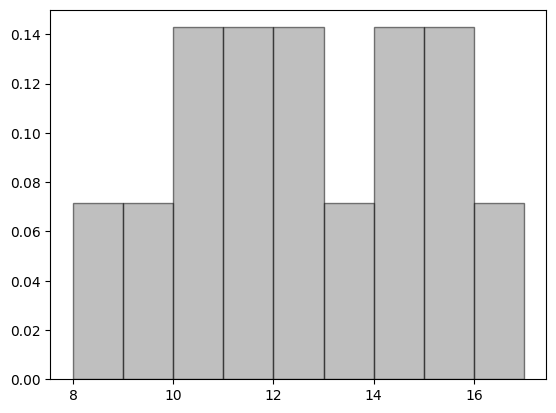

In [9]:
# Gerçek verilerin histogramı
plt.hist(traffic_data, bins=range(min(traffic_data), max(traffic_data) + 2),
         density=True, alpha=0.5, color='gray', edgecolor='black', label='Gerçek Trafik Verisi')

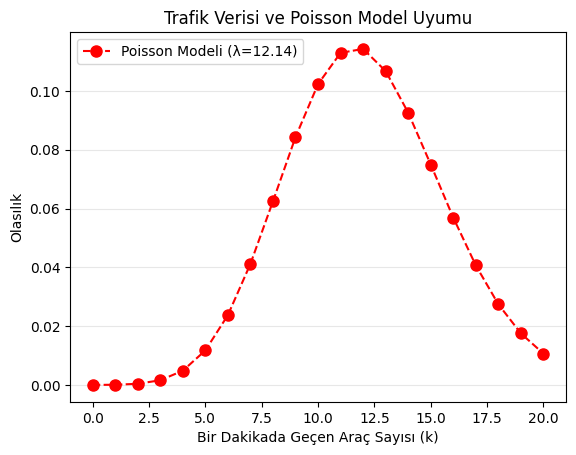

In [11]:
# MLE ile  gelecek tahmin
plt.plot(k_values, model_pmf, 'ro--', markersize=8, label=f'Poisson Modeli (λ={lambda_mle:.2f})')

# Grafik bileşenleri
plt.title('Trafik Verisi ve Poisson Model Uyumu')
plt.xlabel('Bir Dakikada Geçen Araç Sayısı (k)')
plt.ylabel('Olasılık')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
#"Grafik incelendiğinde, Poisson dağılımı eğrisinin gerçek verilerin tepe noktalarıyla genel bir uyum içerisinde olduğu görülmektedir. Verilerin aritmetik ortalaması olan $\lambda = 12.14$ değeri, dağılımın merkezini başarıyla temsil etmektedir. Bu durum, caddeden geçen araç sayısının modellenmesinde Poisson varsayımının ve MLE yönteminin makul bir yaklaşım olduğunu kanıtlar.